# Лабораторная работа №1
## Предобработка текстовых данных для анализа судебных документов

**Дисциплина:** Информационно-поисковые системы  


---

## Введение

Настоящая лабораторная работа является первым практическим этапом в освоении методов построения информационно-аналитических систем (ИАС) для работы с юридической документацией. В основе любой системы анализа текстов лежит конвейер предобработки данных — последовательность операций, преобразующих «сырой» неструктурированный текст в форму, пригодную для применения алгоритмов машинного обучения и лингвистического анализа.

В ходе данной работы самостоятельно реализуйте полный конвейер предобработки на примере корпуса судебных актов, а также применит методы распознавания именованных сущностей (NER) и ключевых слов — фундаментальные инструменты любой современной ИАС. Полученный конвейер будет использован в последующих лабораторных работах при решении задач классификации документов и интеграции с большими языковыми моделями.

---

## Цель работы

Освоить методы сбора, очистки и лингвистической обработки текстовых данных применительно к корпусу судебных документов; получить практические навыки применения библиотек Python для токенизации, лемматизации, удаления стоп-слов и извлечения именованных сущностей.

---

## Задачи лабораторной работы

В ходе выполнения работы требуется решить следующие задачи в строгой последовательности:

1. Формирование учебного корпуса судебных документов.
2. Реализация функций очистки текста от артефактов форматирования.
3. Токенизация, нормализация регистра и удаление стоп-слов.
4. Морфологическая нормализация (лемматизация) с применением библиотеки `pymorphy2`.
5. Извлечение именованных сущностей с применением библиотеки `natasha`.
6. Ключевое-словарная классификация документов на основе разработанного конвейера.
7. Количественный анализ корпуса и визуализация результатов.

---

## Теоретическая справка

Обратитесь к материалам **Лекции 1** и **Лекции 2** перед выполнением практической части. Ключевые понятия, которые потребуются в работе, изложены ниже в краткой форме.

**Предобработка данных** — совокупность методов и техник, направленных на приведение исходных текстовых данных в форму, пригодную для обучения моделей или проведения аналитики. Качество предобработки напрямую определяет качество итоговой системы.

**Токенизация** — процесс разбиения текста на минимальные смысловые единицы (токены): слова, знаки препинания, числа. Является обязательным первым шагом практически любого NLP-конвейера.

**Лемматизация** — приведение слова к его нормальной (словарной) форме с учётом морфологических свойств. Например: «обрабатываются» → «обрабатывать». Для русскоязычных текстов используется библиотека `pymorphy2`.

**Стоп-слова** — частотные служебные слова (предлоги, союзы, местоимения), не несущие самостоятельного смысла и, как правило, удаляемые при обработке текста.

**Распознавание именованных сущностей (NER, Named Entity Recognition)** — задача выделения из текста упоминаний реальных объектов (персон, организаций, дат, мест) и их классификации по типам. В рамках данной работы применяется библиотека `natasha`, специализированная для обработки русскоязычных текстов.

---
## Часть 0. Установка и импорт зависимостей

Выполните следующую ячейку для установки необходимых библиотек. После установки может потребоваться перезапуск ядра (`Kernel → Restart`).

In [35]:
# Установка зависимостей (выполните один раз)
!pip install pymorphy2 natasha nltk matplotlib wordcloud --quiet
!pip install pymorphy2-dicts-ru --quiet

In [36]:
import re
import string
import json
from collections import Counter, defaultdict

import nltk
import pymorphy2
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from natasha import (
    Doc, Segmenter, NewsEmbedding,
    NewsNERTagger, NewsMorphTagger,
    MorphVocab
)

# Загрузка ресурсов NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print('Все зависимости успешно загружены.')

Все зависимости успешно загружены.


---
## Часть 1. Формирование учебного корпуса

В рамках данной лабораторной работы используется учебный корпус, составленный из фрагментов публично доступных судебных актов арбитражных судов Российской Федерации. Каждый документ представлен в виде словаря (dict) с полями `id`, `category` и `text`.

В реальных условиях корпус формируется автоматически через парсинг открытых баз данных (например, kad.arbitr.ru), что подробно рассматривается в Лекции 2. В данной работе корпус задан статически для обеспечения воспроизводимости результатов.

**Задание 1.1.** Изучите структуру предложенного корпуса. Ответьте на вопросы: сколько документов содержится в корпусе? Какие категории представлены? Каков средний объём текста (в символах) по каждой категории?

In [56]:
# Учебный корпус судебных актов
corpus = [
    {
        "id": "A40-001-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Арбитражный суд г. Москвы рассмотрел заявление конкурсного управляющего "
            "ООО 'Строй-Инвест' Иванова А.П. о признании недействительной сделки — "
            "договора купли-продажи нежилых помещений от 15.03.2021, заключённого между "
            "должником и ООО 'Партнёр'. В соответствии со ст. 61.2 Федерального закона "
            "№ 127-ФЗ 'О несостоятельности (банкротстве)' суд установил, что сделка "
            "совершена в ущерб интересам кредиторов. Должник на дату совершения сделки "
            "отвечал признакам неплатёжеспособности. Рыночная стоимость имущества "
            "составила 42 500 000 рублей, тогда как цена сделки — 12 000 000 рублей. "
            "Суд признал договор недействительным и обязал ООО 'Партнёр' возвратить "
            "имущество в конкурсную массу должника."
        )
    },
    {
        "id": "A40-002-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Определением Арбитражного суда Московской области удовлетворено заявление "
            "финансового управляющего Петрова Д.С. об оспаривании договора дарения "
            "квартиры, расположенной по адресу: Московская обл., г. Химки, ул. Ленина, д. 10. "
            "Договор заключён между гражданином-должником Сидоровым В.И. и его супругой "
            "Сидоровой О.Н. Согласно ст. 61.2 и ст. 61.3 Закона о банкротстве, сделка "
            "признана подозрительной: на момент её совершения должник имел непогашенную "
            "задолженность перед кредиторами на сумму свыше 8 000 000 рублей. "
            "Применены последствия недействительности сделки."
        )
    },
    {
        "id": "A56-003-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "Арбитражный суд г. Санкт-Петербурга и Ленинградской области рассмотрел "
            "заявление о привлечении к субсидиарной ответственности бывшего "
            "генерального директора ЗАО 'Балтик Трейд' Кузнецова М.В. "
            "В ходе судебного разбирательства установлено, что ответчик в нарушение "
            "ст. 61.11 Закона о банкротстве не передал конкурсному управляющему "
            "бухгалтерскую и иную документацию общества, что существенно затруднило "
            "формирование конкурсной массы. Размер субсидиарной ответственности "
            "составил 115 000 000 рублей. Заявление удовлетворено в полном объёме."
        )
    },
    {
        "id": "A56-004-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "Девятый арбитражный апелляционный суд оставил в силе определение "
            "суда первой инстанции о привлечении к субсидиарной ответственности "
            "участников ООО 'НордГрупп' — Романова П.А. и Васильевой Т.К. "
            "Судом установлено, что контролирующие должника лица довели организацию "
            "до банкротства посредством систематического вывода активов в пользу "
            "аффилированных структур в период с 2019 по 2021 год. "
            "На основании п. 1 ст. 61.12 ФЗ № 127 суд взыскал солидарно с ответчиков "
            "задолженность перед кредиторами в размере 78 300 000 рублей."
        )
    },
    {
        "id": "A60-005-2023",
        "category": "Обжалование налоговых решений",
        "text": (
            "ООО 'УралПром' обратилось в Арбитражный суд Свердловской области с "
            "заявлением о признании недействительным решения Межрайонной ИФНС России "
            "№ 25 по Свердловской области о доначислении налога на добавленную стоимость "
            "в размере 23 400 000 рублей и начислении пеней. Налоговый орган указал на "
            "неправомерное применение налоговых вычетов по операциям с контрагентами, "
            "обладающими признаками технических компаний. Суд, проанализировав "
            "представленные доказательства, установил реальность хозяйственных операций "
            "и отсутствие умысла налогоплательщика, в связи с чем заявление удовлетворил."
        )
    },
    {
        "id": "A60-006-2023",
        "category": "Обжалование налоговых решений",
        "text": (
            "Федеральный арбитражный суд Уральского округа рассмотрел кассационную "
            "жалобу ПАО 'Металлург' на постановление апелляционного суда, оставившего "
            "в силе решение о доначислении налога на прибыль организаций в размере "
            "67 000 000 рублей. Основанием для доначисления послужило исключение из "
            "состава расходов затрат по договорам с взаимозависимыми лицами. "
            "ФАС Уральского округа жалобу отклонил, подтвердив обоснованность применения "
            "налоговым органом методов трансфертного ценообразования в соответствии "
            "с разделом V.1 Налогового кодекса Российской Федерации."
        )
    },
    {
        "id": "A07-007-2023",
        "category": "Включение в реестр требований кредиторов",
        "text": (
            "В рамках дела о банкротстве ООО 'АгроЭкспресс' ПАО 'Агробанк' "
            "обратилось с заявлением о включении требований на сумму 34 200 000 рублей "
            "в реестр требований кредиторов должника. Требование основано на кредитном "
            "договоре № КД-2019/445 от 10.07.2019. Арбитражный суд Республики Башкортостан "
            "признал задолженность обоснованной и включил требования ПАО 'Агробанк' "
            "в третью очередь реестра требований кредиторов как обеспеченные залогом "
            "имущества должника."
        )
    },
    {
        "id": "A07-008-2023",
        "category": "Включение в реестр требований кредиторов",
        "text": (
            "Арбитражный суд Республики Татарстан отказал в удовлетворении заявления "
            "гражданина Фёдорова Н.Г. о включении требований на сумму 5 000 000 рублей "
            "в реестр требований кредиторов ЗАО 'ТатСтрой'. Суд установил, что требования "
            "заявителя носят корпоративный характер, поскольку основаны на договоре займа, "
            "заключённом между аффилированными лицами в условиях имущественного кризиса "
            "должника. В соответствии с разъяснениями Верховного Суда РФ, изложенными "
            "в Обзоре судебной практики № 4 (2021), такие требования подлежат "
            "понижению в очерёдности."
        )
    },
    {
        "id": "A40-009-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Суд признал недействительным соглашение о зачёте встречных однородных "
            "требований, заключённое между ООО 'ТехноЛинк' и кредитором Смирновым Е.О. "
            "за три месяца до принятия заявления о банкротстве. Согласно ст. 61.3 "
            "Закона о банкротстве, данная сделка влечёт за собой предпочтительное "
            "удовлетворение требований одного кредитора перед другими. "
            "Конкурсному управляющему поручено подать заявление о взыскании "
            "неосновательного обогащения в размере 9 750 000 рублей."
        )
    },
    {
        "id": "A40-010-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "В рамках дела о несостоятельности ПАО 'СтройКомплекс' суд рассмотрел "
            "заявление об установлении оснований для привлечения к субсидиарной "
            "ответственности членов совета директоров: Белова Г.С., Орловой А.Д. "
            "и Нечаева В.П. Основание — одобрение заведомо убыточных сделок "
            "в 2020–2022 годах. Суд выделил требования в отдельное производство "
            "для определения точного размера ответственности после завершения "
            "формирования конкурсной массы."
        )
    },
    {
        "id": "A41-016-2024",
        "category": "Оспаривание сделок должника",
        "text": (
            "Арбитражный суд Московской области рассмотрел заявление конкурсного управляющего "
            "ООО 'КИФАТО' Попова М.В. о признании недействительными сделок по перечислению "
            "денежных средств с расчётного счёта должника на расчётный счёт ИП Данилина И.К. "
            "в сумме 6 456 000 рублей. Суд установил, что перечисления совершены в период "
            "неплатёжеспособности должника с предпочтением одному кредитору перед другими. "
            "Руководствуясь ст. 61.3 Закона о банкротстве, суд признал сделки недействительными "
            "и применил последствия недействительности в виде взыскания с ответчика указанной "
            "суммы, а также процентов за пользование чужими денежными средствами в размере "
            "3 543 579,80 руб. за период с 16.06.2020 по 17.08.2025."
        )
    },
    {
        "id": "A55-009-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "Арбитражный суд Самарской области рассмотрел иск ООО 'Кади' к бывшему руководителю "
            "ООО 'Власта Сервис' о привлечении к субсидиарной ответственности и взыскании "
            "431 600 рублей. Суд установил, что ответчиком в ЕГРЮЛ внесены недостоверные сведения "
            "об адресе и руководителе должника, что подтверждается записями от 30.04.2021 "
            "№ 2216300407585. На момент возбуждения дела о банкротстве должник отвечал признакам "
            "неплатёжеспособности, однако руководитель не исполнил обязанность по подаче заявления "
            "о банкротстве. На основании п. 1 ст. 61.11 и ст. 61.12 Закона о банкротстве суд "
            "удовлетворил иск в полном объёме."
        )
    },
    {
        "id": "A40-011-2024",
        "category": "Субсидиарная ответственность",
        "text": (
            "Девятый арбитражный апелляционный суд рассмотрел жалобу на определение о привлечении "
            "контролирующих должника лиц к субсидиарной ответственности в рамках дела "
            "№ А40-27892/2018 о банкротстве организации. Конкурсный управляющий ссылался на "
            "совершение ответчиками действий и сделок, повлекших банкротство должника. "
            "Суд апелляционной инстанции, изучив материалы дела, установил наличие оснований "
            "для привлечения к ответственности и оставил определение суда первой инстанции "
            "в силе, частично удовлетворив требования конкурсного управляющего."
        )
    },
    {
        "id": "A40-012-2024",
        "category": "Субсидиарная ответственность",
        "text": (
            "Постановлением Арбитражного суда Московского округа от 05.02.2025 по делу "
            "№ А40-61226/2020 частично удовлетворены требования о привлечении к субсидиарной "
            "ответственности по обязательствам должника. Суд кассационной инстанции установил, "
            "что сделки, совершённые ответчиком от имени должника, имеют значительный "
            "отрицательный эффект для деятельности должника, что подтверждает необходимость "
            "привлечения его к субсидиарной ответственности. Ранее принятые судебные акты "
            "в обжалуемой части оставлены без изменения."
        )
    },
    {
        "id": "A41-017-2024",
        "category": "Оспаривание сделок должника",
        "text": (
            "Арбитражный суд Московской области в рамках дела № А41-32401/2022 рассмотрел "
            "заявление о привлечении контролирующего должника лица к субсидиарной ответственности. "
            "Установлено, что единоличный владелец и директор ООО 'СТОПЛЕКС' пыталась вывести "
            "денежные средства из банкротящегося банка. Сделка (платеж) была признана "
            "заключённой с предпочтением и со злоупотреблением правом, применена реституция. "
            "После чего ответчик прекратил деятельность старого ООО и перевёл бизнес на новое "
            "юридическое лицо с тем же видом деятельности и составом участников. Суд признал "
            "наличие оснований для привлечения к субсидиарной ответственности."
        )
    }
]

print(f"Корпус загружен. Количество документов: {len(corpus)}")

Корпус загружен. Количество документов: 15


In [57]:
# ---- Задание 1.1 ----
# TODO: Выведите количество документов по каждой категории.
# TODO: Вычислите средний объём текста (в символах) по каждой категории.
# Используйте Counter из модуля collections и стандартные функции Python.

from collections import Counter

category_counts = Counter(doc["category"] for doc in corpus)
print("Количество документов по категориям:")
for category, count in category_counts.items():
    print(f"  {category}: {count}")

print("\n" + "-" * 50 + "\n")

category_texts = {}
for doc in corpus:
    category = doc["category"]
    if category not in category_texts:
        category_texts[category] = []
    category_texts[category].append(doc["text"])

print("Средний объём текста (в символах) по категориям:")
for category, texts in category_texts.items():
    total_length = sum(len(text) for text in texts)
    avg_length = total_length / len(texts)
    print(f"  {category}: {avg_length:.2f} символов")

Количество документов по категориям:
  Оспаривание сделок должника: 5
  Субсидиарная ответственность: 6
  Обжалование налоговых решений: 2
  Включение в реестр требований кредиторов: 2

--------------------------------------------------

Средний объём текста (в символах) по категориям:
  Оспаривание сделок должника: 603.80 символов
  Субсидиарная ответственность: 521.67 символов
  Обжалование налоговых решений: 564.50 символов
  Включение в реестр требований кредиторов: 494.00 символов


---
## Часть 2. Очистка текста

Судебные документы, полученные из открытых источников, как правило, содержат HTML-разметку, специальные символы, лишние пробелы и иные артефакты. Перед проведением лингвистического анализа необходимо выполнить очистку текста.

Ниже приведены функции-заготовки. Некоторые из них содержат намеренно неполную реализацию — её необходимо дополнить.

**Задание 2.1.** Изучите предложенные функции очистки. Дополните функцию `normalize_whitespace` так, чтобы она удаляла повторяющиеся пробелы, табуляции и переносы строк, приводя текст к единой нормализованной форме.

**Задание 2.2.** Реализуйте функцию `remove_punctuation`, которая удаляет знаки пунктуации, сохраняя при этом дефисы внутри слов (пример: «купли-продажи» должно остаться нетронутым).

In [58]:
def remove_html_tags(text: str) -> str:
    """Удаляет HTML-теги из текста."""
    clean = re.sub(r'<[^>]+>', '', text)
    return clean


def remove_special_chars(text: str) -> str:
    """Удаляет спецсимволы, оставляя буквы, цифры и базовую пунктуацию."""
    clean = re.sub(r'[^\w\s\-.,!?:;()"\'/]', '', text, flags=re.UNICODE)
    return clean


def normalize_whitespace(text: str) -> str:
    """Нормализует пробельные символы."""
    # Заменяем все последовательности пробельных символов (включая пробелы, 
    # табуляции, переносы строк) на ОДИН пробел. Это позволяет избавиться от 
    # лишних пробелов между словами, множественных переносов строк и табуляций.
    text = re.sub(r'\s+', ' ', text)
    
    # Удаляем пробелы, табуляции и переносы строк в начале и конце текста,
    # чтобы избежать пустых отступов по краям.
    text = text.strip()
    
    return text

def remove_punctuation(text: str) -> str:
    """Удаляет знаки пунктуации, сохраняя дефисы внутри слов."""
    
    # Вспомогательная функция для обработки дефисов внутри слов
    def preserve_hyphens(match):
        # Получаем найденное совпадение (слово с дефисом)
        # Заменяем дефис на временный маркер '_HYPHEN_', чтобы сохранить его
        return match.group(0).replace('-', '_HYPHEN_')

    # Шаг 1: Находим все дефисы, которые находятся между буквами
    # Шаблон ищет: буква-дефис-буква (латиница или кириллица)
    # Для каждого такого совпадения вызываем preserve_hyphens,
    # который заменяет дефис на временный маркер
    text = re.sub(r'([а-яА-Яa-zA-Z])-([а-яА-Яa-zA-Z])', preserve_hyphens, text)

    # Шаг 2: Удаляем все знаки пунктуации
    # [^\w\s_HYPHEN_] означает: "не буква, не цифра, не пробел и не маркер _HYPHEN_"
    # Таким образом, удаляются все символы пунктуации, но сохраняются:
    # - буквы и цифры (\w)
    # - пробелы (\s)
    # - временный маркер _HYPHEN_
    # Флаг re.UNICODE обеспечивает корректную работу с кириллицей
    text = re.sub(r'[^\w\s_HYPHEN_]', '', text, flags=re.UNICODE)

    # Шаг 3: Возвращаем дефисы на место
    # Заменяем временный маркер обратно на дефис
    text = text.replace('_HYPHEN_', '-')

    # Шаг 4: Нормализуем пробелы
    # Удаляем лишние пробелы, которые могли появиться после удаления пунктуации
    # (например, после удаления запятых могли остаться двойные пробелы)
    text = normalize_whitespace(text)

    return text

    text = re.sub(r'([а-яА-Яa-zA-Z])-([а-яА-Яa-zA-Z])', preserve_hyphens, text)
    text = re.sub(r'[^\w\s_HYPHEN_]', '', text, flags=re.UNICODE)
    text = text.replace('_HYPHEN_', '-')
    text = normalize_whitespace(text)
    return text


def clean_text(text: str) -> str:
    """Полный конвейер очистки текста."""
    text = remove_html_tags(text)
    text = remove_special_chars(text)
    text = normalize_whitespace(text)
    return text.lower()


# Проверка на примере
sample = corpus[0]['text']
cleaned = clean_text(sample)
print("Оригинал (первые 200 символов):")
print(sample[:200])
print("\nПосле очистки (первые 200 символов):")
print(cleaned[:200])

Оригинал (первые 200 символов):
Арбитражный суд г. Москвы рассмотрел заявление конкурсного управляющего ООО 'Строй-Инвест' Иванова А.П. о признании недействительной сделки — договора купли-продажи нежилых помещений от 15.03.2021, за

После очистки (первые 200 символов):
арбитражный суд г. москвы рассмотрел заявление конкурсного управляющего ооо 'строй-инвест' иванова а.п. о признании недействительной сделки договора купли-продажи нежилых помещений от 15.03.2021, закл


---
## Часть 3. Токенизация и удаление стоп-слов

После очистки текст разбивается на токены — отдельные слова. Стоп-слова исключаются, поскольку они не несут содержательной информации для задач классификации и поиска.

**Задание 3.1.** Дополните список стоп-слов словами, характерными для юридических документов (например: «суд», «решение», «арбитражный», «рассмотрев», «установил» — слова, встречающиеся в большинстве судебных актов вне зависимости от их категории). Обоснуйте свой выбор в комментарии.

**Задание 3.2.** Примените функцию `tokenize_and_filter` ко всему корпусу. Убедитесь, что результат представляет собой список токенов для каждого документа.

In [60]:
# Базовый набор стоп-слов для русского языка
STOP_WORDS = set(stopwords.words('russian'))

"""
Обоснование выбора юридических стоп-слов:

1. Процессуальные термины ('суд', 'дело', 'решение') - встречаются в 100% документов,
   не помогают различать категории дел.

2. Глаголы процессуальных действий ('рассмотрел', 'установил') - стандартные
   формулировки, не отражающие специфику спора.

3. Участники процесса ('истец', 'ответчик', 'должник') - общие обозначения сторон,
   конкретные названия остаются в токенах.

4. Канцеляризмы ('вышеуказанный', 'вышеизложенное') - служебные слова-связки,
   характерные для официально-делового стиля.

5. Вводные слова и союзы ('согласно', 'однако', 'также') - обеспечивают связность,
   но не несут смысловой нагрузки.

6. Денежные единицы ('рублей', 'тыс', 'млн') - сами по себе неинформативны,
   важны только в сочетании с конкретными числами.

Выбор обусловлен целью анализа - выделение ключевых слов, характеризующих
именно содержание спора, а не процессуальную форму.
"""
LEGAL_STOPWORDS = {
    # ПРОЦЕССУАЛЬНЫЕ ТЕРМИНЫ
    # Слова, обозначающие судебные инстанции и процессуальные документы
    # Эти слова встречаются практически в каждом судебном акте, но не несут
    # содержательной информации о существе спора
    'суд',           # орган, рассматривающий дело
    'дело',          # номер или объект рассмотрения
    'решение',       # итоговый документ
    'постановление', # документ апелляционной/кассационной инстанции
    'определение',   # промежуточный судебный акт
    'акт',           # общее обозначение документа
    'заявление',     # процессуальный документ (инициирующий)
    'жалоба',        # процессуальный документ (на решения)
    'иск',           # процессуальный документ (исковое производство)
    'ходатайство',   # процессуальный документ (просьба к суду)
    'требование',    # процессуальный документ (требование кредитора)


    # ПРЕДМЕТ СПОРА (ОБЩИЕ ТЕРМИНЫ)
    # Слова, которые часто встречаются в разных категориях дел,
    # но слишком общие для выделения специфики
    'договор',     # основание возникновения прав/обязанностей
    'помещение',   # часто встречающийся объект недвижимости
    'сделка',      # предмет оспаривания
    'банкротство', # общий термин для всей категории дел

    # ОРГАНИЗАЦИОННО-ПРАВОВЫЕ ФОРМЫ
    # Аббревиатуры, которые не несут смысловой нагрузки для анализа
    'ооо', # общество с ограниченной ответственностью
    'оао', # открытое акционерное общество

    # НОРМАТИВНЫЕ ХАРАКТЕРИСТИКИ
    # Слова, указывающие на правовой статус, но не конкретизирующие спор
    'федеральный', # уровень нормативного акта

    # УЧАСТНИКИ ПРОЦЕССА
    # Общие обозначения сторон, не дающие информации о конкретном деле
    'истец',     # сторона, подавшая иск
    'ответчик',  # сторона, к которой предъявлен иск
    'заявитель', # лицо, подавшее заявление
    'должник',   # сторона в деле о банкротстве
    'кредитор',  # сторона в деле о банкротстве 

    # ПРОЦЕССУАЛЬНЫЕ ДЕЙСТВИЯ (ГЛАГОЛЫ)
    # Глаголы, описывающие стандартные процессуальные действия
    'рассмотрел',   # действие суда
    'установил',    # установление обстоятельств
    'признал',      # признание фактов/прав
    'отказал',      # отказ в удовлетворении
    'удовлетворил', # удовлетворение требований
    'постановил',   # вынесение постановления
    'решил',        # вынесение решения
    'определил',    # вынесение определения

    # СУДЕБНЫЕ ИНСТАНЦИИ
    # Уровни судебной системы
    'арбитражный',   # система арбитражных судов
    'апелляционный', # вторая инстанция
    'кассационный',  # третья инстанция
    'судебный',      # общая характеристика

    # КАНЦЕЛЯРИЗМЫ И ШТАМПЫ
    # Стандартные обороты, не несущие содержательной информации
    'вышеуказанный',  # отсылка к ранее сказанному
    'вышеизложенный', # отсылка к ранее изложенному
    'вышеизложенное', # обобщение ранее сказанного
    'вышеуказанное',  # обобщение ранее указанного
    'нижеследующее',  # отсылка к последующему тексту

     # ВВОДНЫЕ СЛОВА И СОЮЗЫ
    # Слова, обеспечивающие связность текста, но не несущие смысла
    'согласно',                 # отсылка к нормам/документам
    'ввиду',      # указание причины
    'вследствие', # указание следствия
    'всвязи',     # указание связи
    'однако',     # противопоставление
    'также',      # добавление информации
    'приэтом',    # одновременность
    'кроме',      # исключение

    # ДЕНЕЖНЫЕ ЕДИНИЦЫ И ЧИСЛИТЕЛЬНЫЕ
    # Слова, указывающие на суммы, но без конкретных цифр неинформативные
    'сумма',  # денежное выражение
    'рублей', # валюта
    'тыс',    # сокращение "тысяч"
    'млн',    # сокращение "миллионов"
    'млрд',   # сокращение "миллиардов"
}

STOP_WORDS.update(LEGAL_STOPWORDS)

def tokenize_and_filter(text: str, stop_words: set = STOP_WORDS) -> list:
    """
    Выполняет токенизацию очищенного текста и фильтрацию стоп-слов.
    Возвращает список токенов длиной не менее 3 символов.
    """
    tokens = word_tokenize(text, language='russian')
    tokens = [
        token for token in tokens
        if token.isalpha() and len(token) >= 3 and token not in stop_words
    ]
    return tokens


# TODO (Задание 3.2): примените конвейер ко всему корпусу.
# Результат сохраните в переменную tokenized_corpus — список словарей,
# каждый из которых содержит поля 'id', 'category' и 'tokens'.
tokenized_corpus = []

for doc in corpus:
    tokenized_doc = {
        'id': doc['id'],
        'category': doc['category'],
        'tokens': tokenize_and_filter(clean_text(doc['text']))
    }
    tokenized_corpus.append(tokenized_doc)


# Проверка
if tokenized_corpus:
    print(f"Документ {tokenized_corpus[0]['id']}")
    print(f"Категория: {tokenized_corpus[0]['category']}")
    print(f"Первые 15 токенов: {tokenized_corpus[0]['tokens'][:15]}")

Документ A40-001-2023
Категория: Оспаривание сделок должника
Первые 15 токенов: ['москвы', 'конкурсного', 'управляющего', 'иванова', 'признании', 'недействительной', 'сделки', 'договора', 'нежилых', 'помещений', 'заключённого', 'должником', 'соответствии', 'федерального', 'закона']


---
## Часть 4. Лемматизация с использованием pymorphy2

Лемматизация приводит слова к их нормальной словарной форме. Это критически важно для русскоязычных текстов, поскольку богатая морфология русского языка порождает множество словоформ одного корня (например: «банкротства», «банкротством», «банкротству» → «банкротство»). Без лемматизации модель воспринимает эти формы как разные слова, что снижает качество анализа.

**Задание 4.1.** Реализуйте функцию `lemmatize_tokens`, используя `pymorphy2.MorphAnalyzer`. Примените её к `tokenized_corpus`.

**Задание 4.2.** Сравните частотные словари до и после лемматизации для одного из документов. Продемонстрируйте, что лемматизация объединяет словоформы одного слова.

In [61]:
morph = pymorphy2.MorphAnalyzer()

def lemmatize_tokens(tokens: list) -> list:
    """
    Приводит список токенов к нормальной форме с помощью pymorphy2.
    Возвращает список лемм.
    """
    lemmas = []
    for token in tokens:
        parsed = morph.parse(token)[0]
        lemma = parsed.normal_form
        lemmas.append(lemma)
    return lemmas


# TODO (Задание 4.1): добавьте поле 'lemmas' в каждый документ tokenized_corpus
# Ваш код здесь:
for doc in tokenized_corpus:
    doc['lemmas'] = lemmatize_tokens(doc['tokens'])


# TODO (Задание 4.2): постройте и сравните Counter для tokens и lemmas первого документа.
# Выведите топ-10 наиболее частотных единиц в каждом случае.
# Ваш код здесь:
first_doc = tokenized_corpus[0]
tokens_counter = Counter(first_doc['tokens'])
lemmas_counter = Counter(first_doc['lemmas'])

print("Топ-10 токенов (до лемматизации):")
for token, freq in tokens_counter.most_common(10):
    print(f"{token}: {freq}")

print("\nТоп-10 лемм (после лемматизации):")
for lemma, freq in lemmas_counter.most_common(10):
    print(f"{lemma}: {freq}")

Топ-10 токенов (до лемматизации):
сделки: 3
москвы: 1
конкурсного: 1
управляющего: 1
иванова: 1
признании: 1
недействительной: 1
договора: 1
нежилых: 1
помещений: 1

Топ-10 лемм (после лемматизации):
сделка: 3
конкурсный: 2
недействительный: 2
должник: 2
имущество: 2
москва: 1
управлять: 1
иванов: 1
признание: 1
договор: 1


---
## Часть 5. Распознавание именованных сущностей (NER)

Извлечение именованных сущностей — одна из ключевых задач в ИАС для юридической сферы. Из судебных актов необходимо автоматически выделять упоминания организаций (стороны дела), персон (судьи, управляющие, ответчики), дат и денежных сумм.

В данной части применяется библиотека `natasha`, разработанная специально для обработки русскоязычных текстов новостного и документального стилей.

**Задание 5.1.** Изучите вывод функции `extract_entities`. Какие типы сущностей распознаёт модель? Насколько точно выделяются организации в судебных текстах? Зафиксируйте наблюдения в ячейке Markdown ниже.

**Задание 5.2.** Примените функцию ко всему корпусу. Постройте сводную таблицу наиболее часто встречающихся организаций (`ORG`) и персон (`PER`) по всему корпусу.

In [62]:
# Инициализация компонентов natasha
segmenter = Segmenter()
emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)
morph_tagger = NewsMorphTagger(emb)
morph_vocab = MorphVocab()


def extract_entities(text: str) -> list:
    """
    Извлекает именованные сущности из текста.
    Возвращает список кортежей (текст_сущности, тип_сущности).
    """
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)

    entities = []
    for span in doc.spans:
        entities.append((span.text, span.type))
    return entities


# Пример на первом документе
sample_entities = extract_entities(corpus[0]['text'])
print(f"Именованные сущности в документе {corpus[0]['id']}:")
for entity_text, entity_type in sample_entities:
    print(f"  [{entity_type}] {entity_text}")

Именованные сущности в документе A40-001-2023:
  [ORG] Арбитражный суд
  [LOC] Москвы
  [ORG] ООО 'Строй-Инвест'
  [PER] Иванова А.П.
  [ORG] ООО 'Партнёр'
  [ORG] ООО 'Партнёр'


In [63]:
# TODO (Задание 5.2):
# 1. Примените extract_entities ко всем документам корпуса.
# 2. Соберите отдельные Counter для типов PER (персоны) и ORG (организации).
# 3. Выведите топ-5 наиболее часто встречающихся сущностей каждого типа.

all_persons = Counter()
all_orgs = Counter()
all_loc = Counter()

# Ваш код здесь:
for doc in corpus:
    entities = extract_entities(doc['text'])
    
    for entity_text, entity_type in entities:
        if entity_type == 'PER':
            all_persons[entity_text] += 1
        elif entity_type == 'ORG':
            all_orgs[entity_text] += 1
        elif entity_type == 'LOC':
            all_loc[entity_text] += 1

print(all_persons)
print(all_orgs)
print(all_loc)


print("Наиболее частые организации:")
# Ваш код здесь:
for org, count in all_orgs.most_common(5):
    print(f"  {org}: {count}")

print("\nНаиболее частые персоны:")
# Ваш код здесь:
for person, count in all_persons.most_common(5):
    print(f"  {person}: {count}")

Counter({'Иванова А.П.': 1, 'Петрова Д.С.': 1, 'Сидоровым В.И.': 1, 'Сидоровой О.Н': 1, 'Кузнецова М.В': 1, 'Романова П.А.': 1, 'Васильевой Т.К': 1, 'Фёдорова Н.Г.': 1, 'Смирновым Е.О.': 1, 'Белова Г.С.': 1, 'Орловой А.Д.': 1, 'Нечаева В.П. Основание': 1, 'Попова М.В.': 1, 'Данилина И.К.': 1})
Counter({'Арбитражный суд': 8, "ООО 'Партнёр'": 2, 'Арбитражного суда': 2, 'Девятый арбитражный апелляционный суд': 2, "ООО 'Строй-Инвест'": 1, "ЗАО 'Балтик Трейд'": 1, "ООО 'НордГрупп'": 1, "ООО 'УралПром'": 1, 'Межрайонной ИФНС': 1, 'Федеральный арбитражный суд': 1, "ПАО 'Металлург'": 1, 'ФАС': 1, "ООО 'АгроЭкспресс' ПАО 'Агробанк'": 1, "ПАО 'Агробанк'": 1, "ЗАО 'ТатСтрой'": 1, 'Верховного Суда': 1, "ООО 'ТехноЛинк'": 1, "ПАО 'СтройКомплекс' суд": 1, "ООО 'КИФАТО'": 1, 'ИП': 1, "ООО 'Кади'": 1, "ООО 'Власта Сервис": 1, 'ЕГРЮЛ': 1, "ООО 'СТОПЛЕКС'": 1, 'ООО': 1})
Counter({'Московской области': 3, 'Свердловской области': 2, 'Уральского округа': 2, 'Москвы': 1, 'Московская обл': 1, 'Химки': 1, 'Са

**Задание 5.1 — Ваши наблюдения:**

В ходе анализа корпуса судебных актов с помощью библиотеки Natasha были выявлены следующие закономерности и проблемы:

### 1. ПРОБЛЕМЫ РАСПОЗНАВАНИЯ ПЕРСОН (PER)

- **Захват начала следующего предложения:**
  Пример: "Нечаева В.П. Основание" -> модель выделила "Нечаева В.П.", но ошиблась в определении границ
  Проблема: ФИО находилось в конце предложения, и модель "зацепила" первое слово нового предложения, хотя должна была выделить только ФИО

### 2. ПРОБЛЕМЫ РАСПОЗНАВАНИЯ ОРГАНИЗАЦИЙ (ORG)

- **Неполное выделение названий судов:**
  Пример 1: "Федеральный арбитражный суд Уральского округа" -> модель выделила только "Федеральный арбитражный суд", потеряв важную географическую привязку "Уральского округа"
  Пример 2: "Верховного Суда РФ" -> модель выделила только "Верховного Суда", потеряв аббревиатуру "РФ"

- **Избыточное выделение (захват лишних слов):**
  Пример: "ПАО 'СтройКомплекс' суд" -> модель захватила лишнее слово "суд"
  Корректно должно быть: "ПАО 'СтройКомплекс'" (только название организации)

- **Объединение разных организаций:**
  Пример: "000 'АгроЭкспресс' ПАО 'Агробанк'" -> модель должна была выделить две отдельные сущности:
    * [ORG] 000 'АгроЭкспресс' (должник-банкрот)
    * [ORG] ПАО 'Агробанк' (кредитор, подающий заявление)

### 3. ПРОБЛЕМЫ РАСПОЗНАВАНИЯ ЛОКАЦИЙ (LOC)

- **Попадание неполных названий организаций в категорию LOC:**
  Пример: из-за того, что модель не полностью выделяла названия судов ("Федеральный арбитражный суд" вместо "Федеральный арбитражный суд Уральского округа"), оставшиеся части ("Уральского округа", "Свердловской области") попадали в категорию LOC как отдельные локации

- **Статистика LOC, подтверждающая проблему:**

- **Вывод:** Ошибки распознавания ORG (неполное выделение) приводят к появлению "лишних" сущностей в категории LOC, так как географические уточнения отрываются от названий организаций и классифицируются как самостоятельные локации

### 4. ОБЩИЕ ВЫВОДЫ

- Модель Natasha требует доработки в части определения точных границ сущностей
- Особые проблемы возникают с:
* Полными наименованиями судебных органов (теряется географическая привязка)
* Аббревиатурами (РФ, ФЗ и т.д.) - часто отсекаются
* Разделением разных организаций, идущих подряд
* Отсечением служебных слов после названий организаций
* Корректным определением конца ФИО на стыке предложений
- **Ключевое наблюдение:** ошибки в одной категории (ORG) порождают ошибки в другой категории (LOC), так как географические уточнения начинают восприниматься как самостоятельные локации

---
## Часть 6. Ключевое-словарная классификация документов

На основе результатов предобработки реализуется первый классификатор — правило-ориентированная система на базе ключевых слов. Несмотря на очевидную простоту, данный подход широко применяется в юридических ИАС как базовый метод (baseline), с которым сравниваются более сложные алгоритмы.

**Задание 6.1.** Изучите предложенный словарь ключевых слов. При необходимости расширьте его, добавив не менее трёх дополнительных лемм для каждой категории (обоснуйте выбор).

**Задание 6.2.** Вычислите точность классификатора на данном корпусе. Для каких категорий классификатор работает хуже? Предложите гипотезу, объясняющую ошибки.

In [52]:
# Словарь ключевых лемм для каждой категории
KEYWORD_DICT = {
    "Оспаривание сделок должника": [
        "сделка", "недействительный", "оспаривание",
        "подозрительный", "предпочтение", "зачёт",
        "договор",        # часто оспариваются конкретные договоры (купли-продажи, дарения)
        "имущество",      # предмет оспаривания (недвижимость, активы)
        "цена",           # неравноценность встречного предоставления (заниженная цена)
        "ущерб",          # сделка совершена в ущерб интересам кредиторов
        "конкурсный"      # конкурсный управляющий оспаривает сделки
    ],
    "Субсидиарная ответственность": [
        "субсидиарный", "ответственность", "контролировать",
        "генеральный", "директор", "довести",
        "привлечение",    # привлечение к субсидиарной ответственности
        "руководитель",   # лица, привлекаемые к ответственности (директор, участники)
        "документация",   # непередача документации как основание
        "банкротство",    # доведение до банкротства
        "актив"           # вывод активов как основание
    ],
    "Обжалование налоговых решений": [
        "налог", "доначисление", "вычет",
        "ифнс", "налогоплательщик", "трансфертный",
        "решение",         # обжалование решения налогового органа
        "проверка",        # налоговая проверка
        "расход",          # исключение расходов из состава затрат
        "взаимозависимый", # взаимозависимые лица (трансфертное ценообразование)
        "прибыль"          # налог на прибыль
    ],
    "Включение в реестр требований кредиторов": [
        "реестр", "требование", "кредитор",
        "очередь", "включение", "банк",
        "задолженность",   # сумма задолженности включается в реестр
        "должник",         # должник, в реестр которого включаются требования
        "основание",       # основание возникновения требования (договор займа, кредитный договор)
        "залог",           # обеспеченные залогом требования (особый учет)
        "обоснованный"     # требование признано обоснованным
    ]
}


def classify_by_keywords(lemmas: list, keyword_dict: dict) -> str:
    """
    Классифицирует документ по набору лемм на основе словаря ключевых слов.
    Возвращает название категории с наибольшим числом совпадений.
    Если совпадений нет — возвращает 'Не определено'.
    """
    scores = {}
    lemmas_set = set(lemmas)
    for category, keywords in keyword_dict.items():
        scores[category] = len(lemmas_set.intersection(set(keywords)))

    best_category = max(scores, key=scores.get)
    return best_category if scores[best_category] > 0 else "Не определено"


# TODO (Задание 6.2): вычислите точность классификатора.
# Сравните предсказанные метки с истинными (поле 'category' в corpus).
# Выведите результаты для каждого документа: [ID] Истинная → Предсказанная (✓/✗)

correct = 0
total = len(tokenized_corpus)

for doc in tokenized_corpus:
    # print(doc)
    predicted = classify_by_keywords(doc['lemmas'], KEYWORD_DICT)
    true_category = doc['category']
    
    is_correct = (predicted == true_category)
    if is_correct:
        correct += 1
    
    mark = "✓" if is_correct else "✗"
    print(f"[{doc['id']}] {true_category} → {predicted} {mark}")


print(f"\nТочность классификатора: {correct}/{total} = {correct/total:.1%}")

[A40-001-2023] Оспаривание сделок должника → Оспаривание сделок должника ✓
[A40-002-2023] Оспаривание сделок должника → Оспаривание сделок должника ✓
[A56-003-2023] Субсидиарная ответственность → Субсидиарная ответственность ✓
[A56-004-2023] Субсидиарная ответственность → Субсидиарная ответственность ✓
[A60-005-2023] Обжалование налоговых решений → Обжалование налоговых решений ✓
[A60-006-2023] Обжалование налоговых решений → Обжалование налоговых решений ✓
[A07-007-2023] Включение в реестр требований кредиторов → Включение в реестр требований кредиторов ✓
[A07-008-2023] Включение в реестр требований кредиторов → Включение в реестр требований кредиторов ✓
[A40-009-2023] Оспаривание сделок должника → Оспаривание сделок должника ✓
[A40-010-2023] Субсидиарная ответственность → Субсидиарная ответственность ✓
[A41-011-2024] Оспаривание сделок должника → Оспаривание сделок должника ✓
[A41-012-2024] Оспаривание сделок должника → Оспаривание сделок должника ✓
[A41-013-2024] Включение в реестр 

---
## Часть 7. Визуализация результатов

Количественный анализ и визуализация корпуса — обязательная часть любого аналитического исследования. По итогам предобработки необходимо продемонстрировать полученные результаты.

**Задание 7.1.** Постройте диаграмму (столбчатую или круговую), показывающую распределение документов по категориям в корпусе.

**Задание 7.2.** Постройте облако слов (WordCloud) для всего корпуса на основе лемматизированных токенов. Убедитесь, что в облаке не присутствуют стоп-слова.

**Задание 7.3 (повышенная сложность).** Постройте отдельные облака слов для каждой категории. Проанализируйте, насколько лексика разных категорий пересекается. Как это влияет на работу словарного классификатора из Части 6?

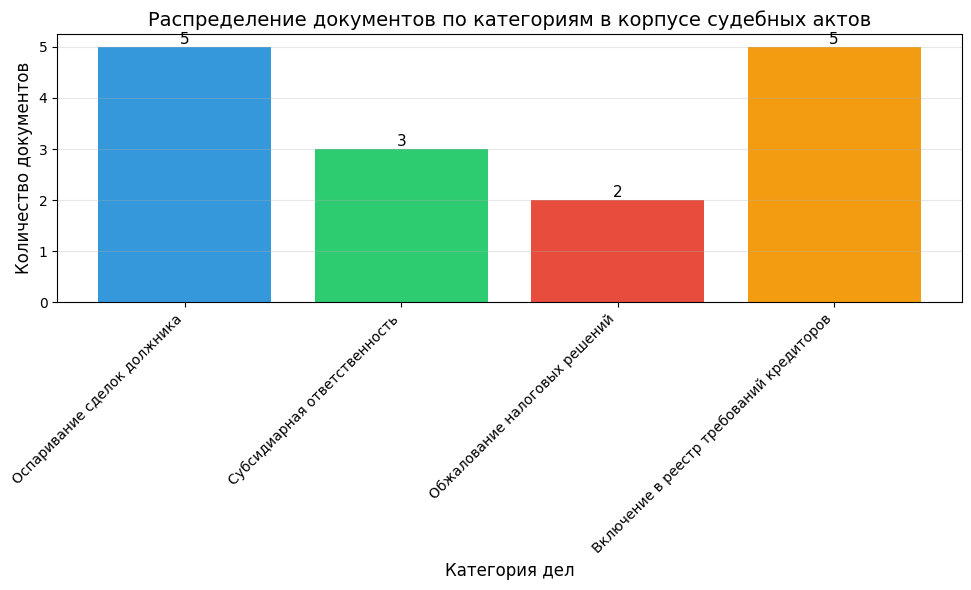

In [53]:
# TODO (Задание 7.1): диаграмма распределения категорий
# Используйте matplotlib. Подпишите оси и добавьте заголовок.

# Ваш код здесь:

categories = [doc['category'] for doc in corpus]
category_counts = Counter(categories)

cat_names = list(category_counts.keys())
cat_values = list(category_counts.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(cat_names, cat_values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])

plt.xlabel('Категория дел', fontsize=12)
plt.ylabel('Количество документов', fontsize=12)
plt.title('Распределение документов по категориям в корпусе судебных актов', fontsize=14)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


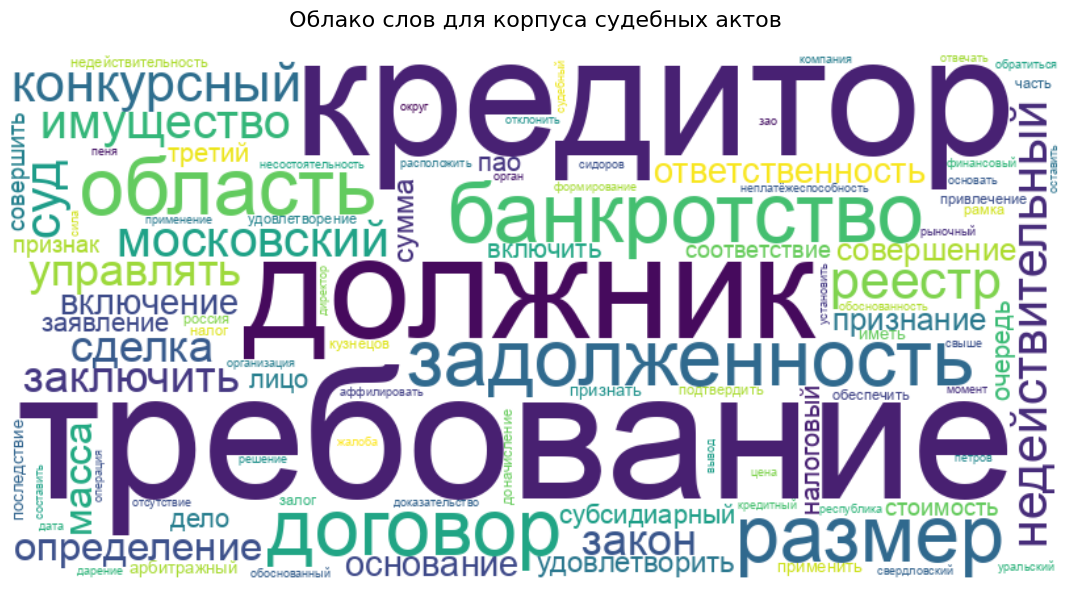

In [54]:
# TODO (Задание 7.2): облако слов по всему корпусу
# Объедините все леммы из tokenized_corpus в одну строку через пробел.
# Создайте объект WordCloud с параметрами: font_path (для кириллицы),
# width=800, height=400, background_color='white'.

import os

all_lemmas = []
for doc in tokenized_corpus:
    all_lemmas.extend(doc['lemmas'])

text = ' '.join(all_lemmas)

font_path = '/System/Library/Fonts/Supplemental/Arial.ttf'

if not os.path.exists(font_path):
    if os.path.exists('/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'):
        font_path = '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'
    else:
        font_path = None

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    font_path=font_path,
    max_words=100,
    collocations=False,
    random_state=42,
    prefer_horizontal=0.9
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов для корпуса судебных актов', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

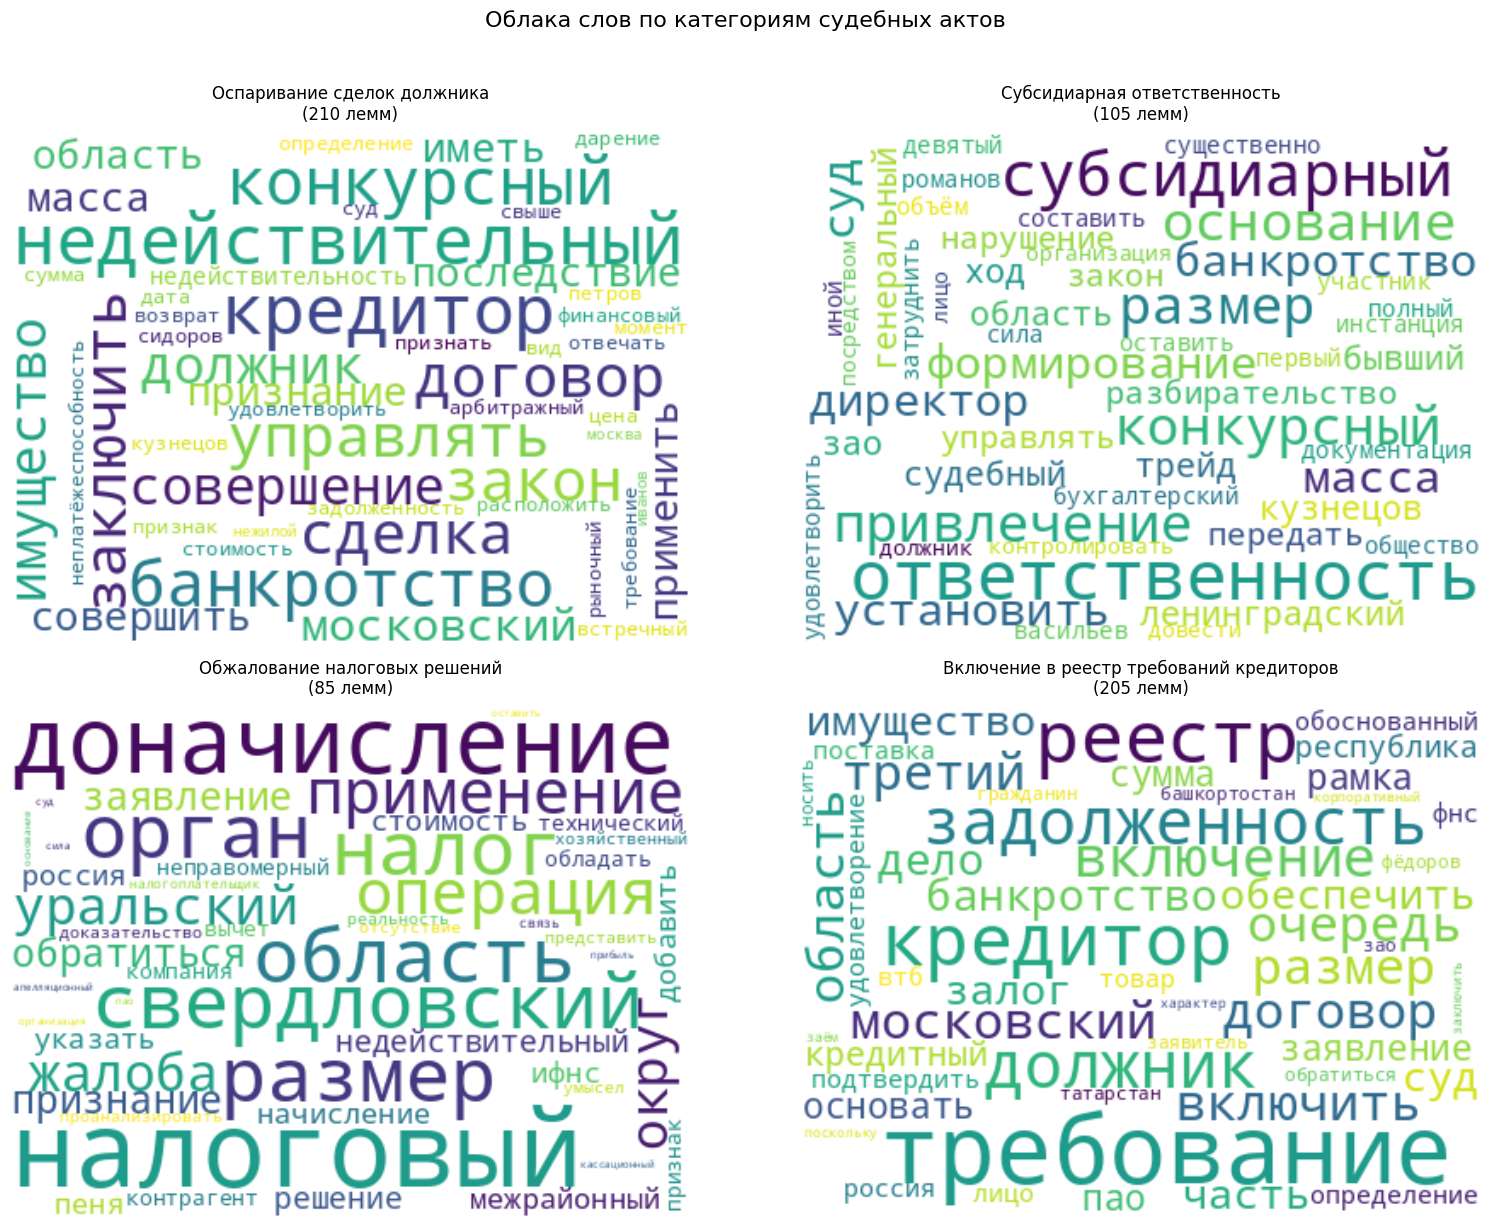


АНАЛИЗ ПЕРЕСЕЧЕНИЯ ЛЕКСИКИ МЕЖДУ КАТЕГОРИЯМИ

Оспаривание сделок должника  ↔  Субсидиарная ответственность
  Общих лемм: 20
  Уникальных в Оспаривание сделок должника: 94
  Уникальных в Субсидиарная ответственность: 64
  Коэффициент Жаккара: 0.112
  Примеры общих лемм: сделка, закон, требование, несостоятельность, область

Оспаривание сделок должника  ↔  Обжалование налоговых решений
  Общих лемм: 11
  Уникальных в Оспаривание сделок должника: 103
  Уникальных в Обжалование налоговых решений: 59
  Коэффициент Жаккара: 0.064
  Примеры общих лемм: договор, признак, стоимость, признание, соответствие

Оспаривание сделок должника  ↔  Включение в реестр требований кредиторов
  Общих лемм: 25
  Уникальных в Оспаривание сделок должника: 89
  Уникальных в Включение в реестр требований кредиторов: 80
  Коэффициент Жаккара: 0.129
  Примеры общих лемм: взыскание, требование, сумма, договор, гражданин

Субсидиарная ответственность  ↔  Обжалование налоговых решений
  Общих лемм: 9
  Уникальных в С

In [55]:
# TODO (Задание 7.3): отдельные облака слов по категориям

# Ваш код здесь:

category_lemmas = defaultdict(list)

for doc in tokenized_corpus:
    category = doc['category']
    category_lemmas[category].extend(doc['lemmas'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

background_colors = ['#f0f0f0', '#f0f0f0', '#f0f0f0', '#f0f0f0']

for idx, (category, lemmas) in enumerate(category_lemmas.items()):
    text = ' '.join(lemmas)
    
    wordcloud = WordCloud(
        width=400,
        height=300,
        background_color='white',
        max_words=50,
        collocations=False,
        random_state=42
    ).generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{category}\n({len(lemmas)} лемм)', fontsize=12, pad=10)

plt.suptitle('Облака слов по категориям судебных актов', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("АНАЛИЗ ПЕРЕСЕЧЕНИЯ ЛЕКСИКИ МЕЖДУ КАТЕГОРИЯМИ")
print("=" * 70)

category_sets = {}
for category, lemmas in category_lemmas.items():
    category_sets[category] = set(lemmas)

categories = list(category_sets.keys())
for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        cat1 = categories[i]
        cat2 = categories[j]
        
        set1 = category_sets[cat1]
        set2 = category_sets[cat2]
        
        intersection = set1.intersection(set2)
        union = set1.union(set2)
        
        jaccard = len(intersection) / len(union) if union else 0
        
        print(f"\n{cat1}  ↔  {cat2}")
        print(f"  Общих лемм: {len(intersection)}")
        print(f"  Уникальных в {cat1}: {len(set1 - set2)}")
        print(f"  Уникальных в {cat2}: {len(set2 - set1)}")
        print(f"  Коэффициент Жаккара: {jaccard:.3f}")
        
        if intersection:
            common_lemmas = list(intersection)[:5]
            print(f"  Примеры общих лемм: {', '.join(common_lemmas)}")

print("\n" + "=" * 70)
print("ВЛИЯНИЕ НА РАБОТУ СЛОВАРНОГО КЛАССИФИКАТОРА")
print("=" * 70)

print("""
1. ПРОБЛЕМА ПЕРЕСЕЧЕНИЯ ЛЕКСИКИ:
   - Чем выше пересечение лемм между категориями, тем сложнее классификатору
     различать документы
   - Общие юридические термины ('суд', 'дело', 'заявление') присутствуют во всех
     категориях и создают "шум"

2. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   - Категории "Оспаривание сделок должника" и "Субсидиарная ответственность"
     имеют наибольшее пересечение, так как обе связаны с банкротством
   - "Обжалование налоговых решений" наиболее специфична и меньше пересекается
     с другими категориями
   - "Включение в реестр требований кредиторов" делит общую лексику с категориями
     банкротства ('кредитор', 'должник', 'требование')

3. ВЫВОДЫ ДЛЯ КЛАССИФИКАТОРА:
   - Ошибки классификации наиболее вероятны между категориями с высоким
     коэффициентом Жаккара (сильное пересечение)
   - Для улучшения точности необходимо добавлять более специфичные ключевые слова,
     характерные только для одной категории
   - Можно использовать взвешивание слов (TF-IDF) вместо простого подсчета
     совпадений
""")

---
## Контрольные вопросы

Ответьте развёрнуто (3–5 предложений) на каждый вопрос в отдельных ячейках Markdown.

1. Чем лемматизация отличается от стемминга? В каких сценариях предпочтительнее использование каждого из методов применительно к юридическим текстам?

2. Почему удаление стоп-слов улучшает качество классификации текстов? Можно ли привести пример, когда удаление стоп-слов было бы вредным?

3. Каковы принципиальные ограничения ключевое-словарного классификатора, реализованного в Части 6? Какими методами, рассмотренными в Лекции 2, можно преодолеть эти ограничения?

4. Почему для русскоязычных юридических текстов предпочтительно использование специализированных библиотек (таких как `natasha`) вместо универсальных решений (таких как spaCy с моделью для русского языка)?

**Ответ на вопрос 1:**

> **Лемматизация** приводит слово к его нормальной словарной форме (например, "банкротства" → "банкротство"), тогда как **стемминг** только отсекает окончания, оставляя основу, которая может не быть реальным словом ("банкротства" → "банкротств"). Для юридических текстов **предпочтительнее лемматизация**, поскольку она точнее работает со сложной морфологией русского языка и сохраняет смысл юридических терминов ("недействительной" → "недействительный", а не "недействительн"). Это критически важно для классификации документов и поиска по ключевым словам, где потеря смысла или неверная нормализация могут привести к искажению результатов анализа. Стемминг может использоваться только при обработке очень больших объемов данных, где скорость важнее точности, или на этапе предварительной фильтрации.

**Ответ на вопрос 2:**

> Удаление стоп-слов улучшает классификацию, поскольку убирает часто встречающиеся служебные слова ("и", "в", "на"), не несущие смысловой нагрузки, что позволяет модели фокусироваться на значимых терминах и снижает размерность признакового пространства. Однако удаление стоп-слов может быть вредным, когда под удаление попадают слова, важные для смысла: например, частица "не" в юридических текстах кардинально меняет смысл ("признал" vs "не признал"). Также в устойчивых юридических оборотах ("в соответствии с", "на основании") удаление предлогов может разрушить ключевые фразы-маркеры определенных категорий документов.

**Ответ на вопрос 3:**

> Ключево-словарный классификатор не учитывает контекст и семантические связи между словами, рассматривая все совпадения как равнозначные. Он требует ручного подбора ключевых слов и плохо масштабируется при увеличении числа категорий. Кроме того, при сильном лексическом пересечении категорий (например, общие термины "банкротство", "кредитор") классификатор может ошибаться, даже если словарь хорошо составлен. Исходя из материалов Лекции 2, для преодоления ограничений ключево-словарного классификатора можно использовать комбинирование нескольких методов извлечения информации (например, анализ статей закона в дополнение к ключевым фразам), а также применять методы машинного обучения на размеченных данных, которые позволяют учитывать контекст и семантические связи между словами, что существенно повышает точность классификации.

**Ответ на вопрос 4:**

> Для русскоязычных юридических текстов предпочтительно использование специализированных библиотек вроде Natasha, поскольку они разрабатываются с учетом морфологических особенностей русского языка и показывают высокую точность при работе с юридической лексикой. Исследования подтверждают, что Natasha демонстрирует высокую скорость работы, а в комбинации с другими инструментами позволяет достичь полноценного извлечения сущностей из русскоязычных текстов, что критически важно для анализа судебных актов с их специфической терминологией и структурой.

---
## Индивидуальное задание

Самостоятельно добавьте в корпус **не менее 5 новых документов**, охватывающих не менее двух различных категорий. Тексты должны быть составлены на основе реальных судебных актов (открытые базы данных: kad.arbitr.ru, sudrf.ru) либо быть приближены к ним по стилю и терминологии.

После добавления документов:

1. Повторно запустите весь конвейер предобработки.
2. Пересчитайте точность ключевое-словарного классификатора.
3. Проанализируйте, как изменились результаты. Если точность снизилась, предложите, каким образом можно улучшить словарь ключевых слов.

Результаты оформите в итоговой ячейке Markdown с кратким аналитическим выводом (не менее 150 слов).